# Credit Card Risk Prediction

In [1]:
# Importing Libraries
import warnings
warnings.filterwarnings('ignore')
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve


# Data Collection
df = pd.read_csv("Credit_Card_Risk_Prediction.csv")
df.columns = df.columns.str.replace(" ", "_")
display(df.head(5))
display(df.info())
display(df.describe())


# Data Cleaning
df["Checking_account"] = df["Checking_account"].fillna("No Account")
df["Saving_accounts"] = df["Saving_accounts"].fillna("No Account")

,Age,Sex,Job,Housing,Saving_accounts,Checking_account,Credit_amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving_accounts   817 non-null    str  
 5   Checking_account  606 non-null    str  
 6   Credit_amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


None

,Age,Job,Credit_amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


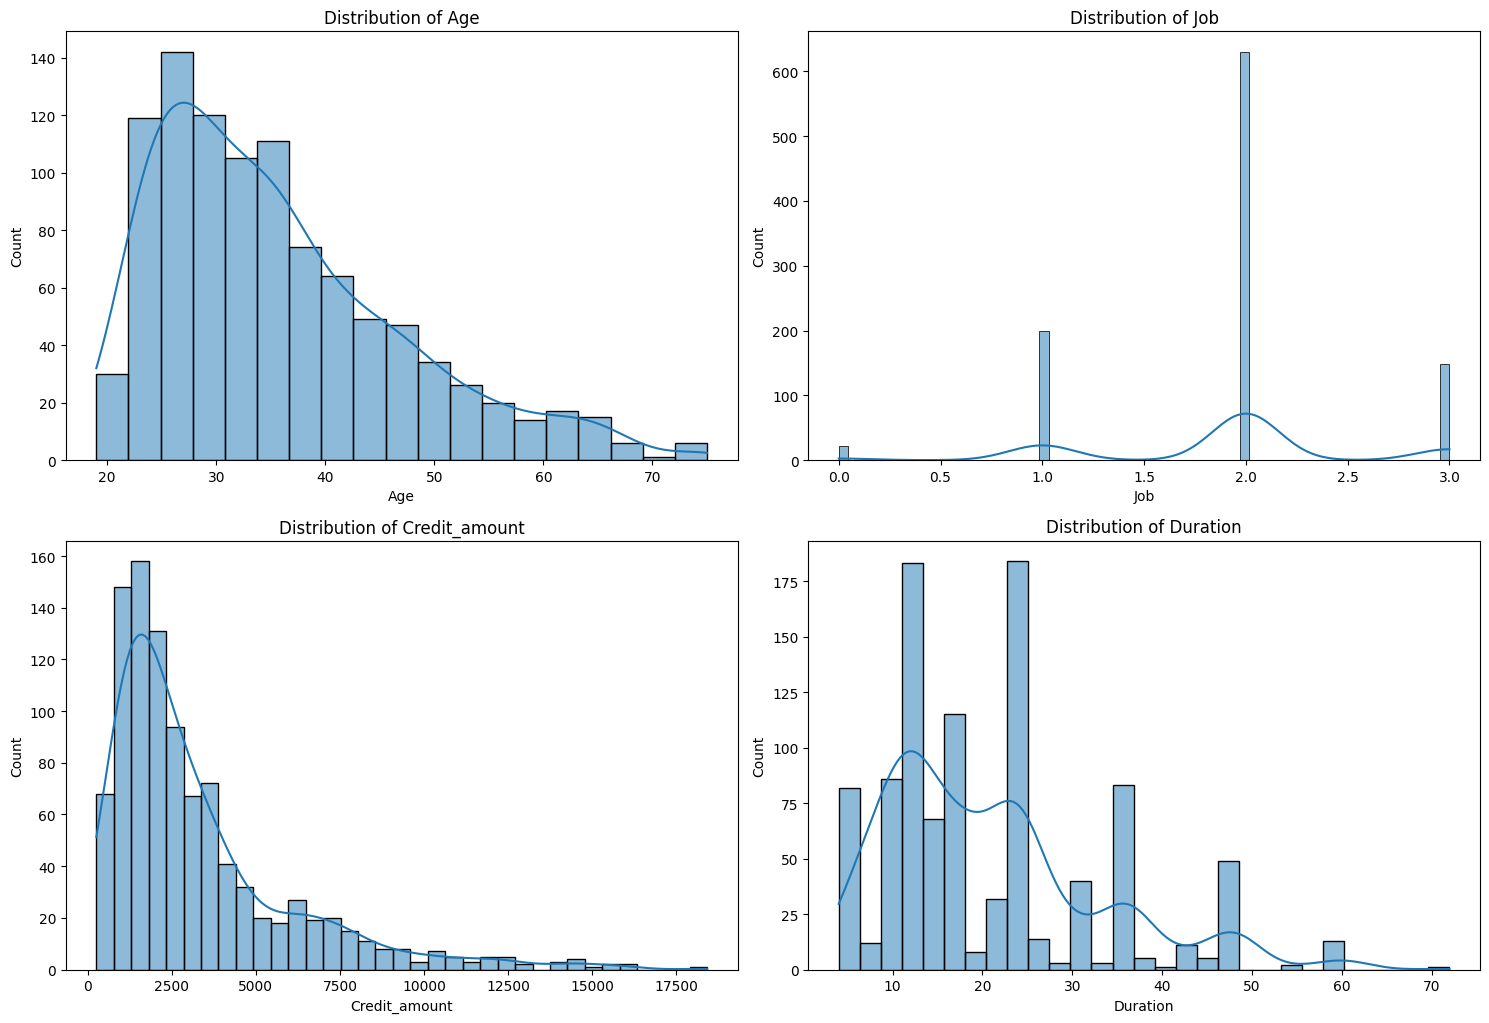

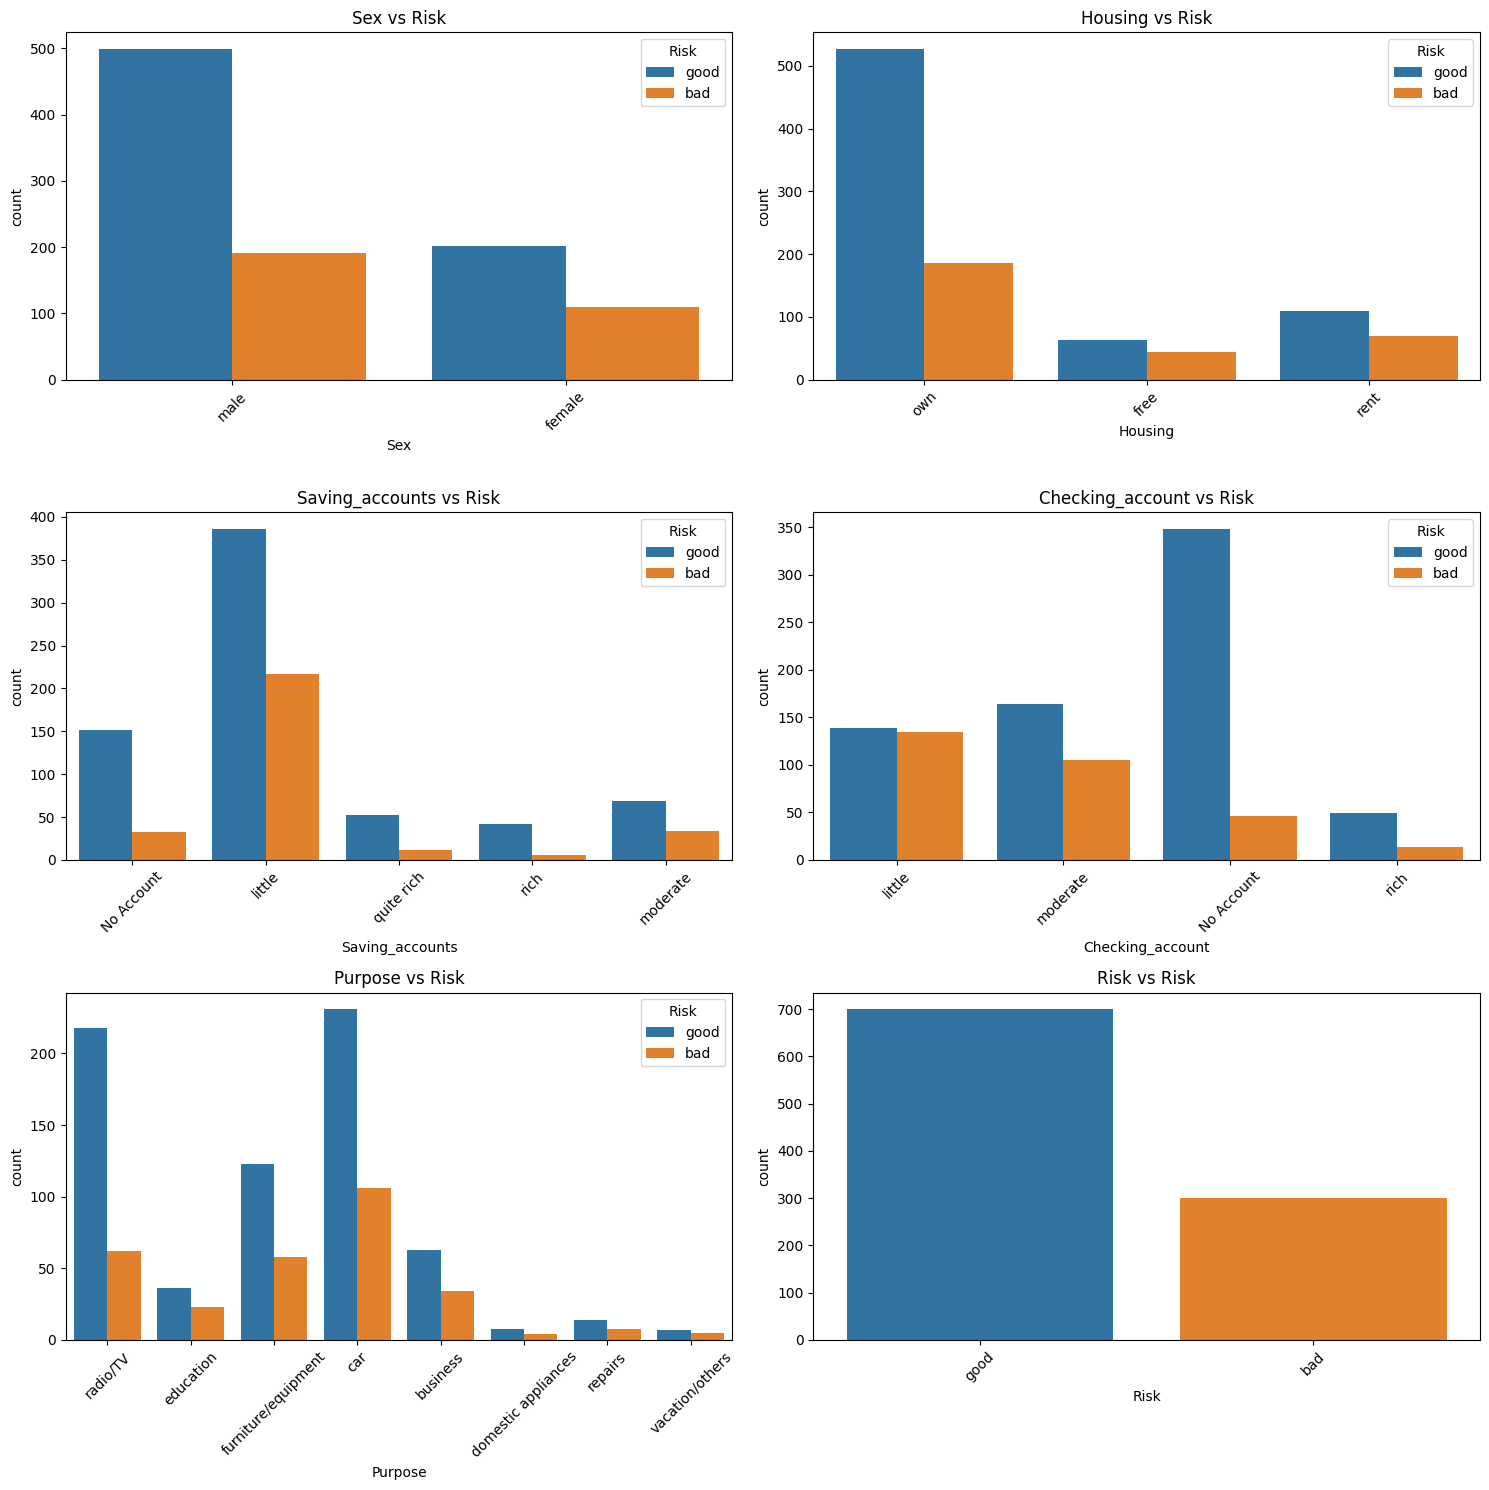

In [2]:
# Data Visualization
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["str"]).columns
    
## Univariate - Distribution of Numerical dataset
plt.figure(figsize=(15, 15))
for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(f'{col}')  

plt.tight_layout()
plt.show()
    
## Multivariate - Feature vs Target
plt.figure(figsize=(15, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(3, 2, i + 1)
    sns.countplot(x=col, hue='Risk', data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Risk')

plt.tight_layout()
plt.show()

In [3]:
# Train Test Split
X = df.drop("Risk", axis=1)
y = df["Risk"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# Pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, make_column_selector(dtype_include=np.number)),
    ("cat", cat_pipeline, make_column_selector(dtype_exclude=np.number))
])

In [4]:
# Model Training
log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42))  
])
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(probability=True, class_weight="balanced", random_state=42)) 
])
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42, eval_metric="logloss")) 
])
ann_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42))
])

log_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
svm_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)
ann_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [5]:
# Model Evaluation 
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, y_prob)
    
    print(name)
    print(f"ROC-AUC  : {roc:.4f}")
    return roc


roc_log = evaluate_model(log_pipeline, "Logistic Regression")
roc_rf = evaluate_model(rf_pipeline, "Random Forest")
roc_svm = evaluate_model(svm_pipeline, "SVM")
roc_xgb = evaluate_model(xgb_pipeline, "XGB")
roc_ann = evaluate_model(ann_pipeline, "ANN")

Logistic Regression
ROC-AUC  : 0.7508
Random Forest
ROC-AUC  : 0.7533
SVM
ROC-AUC  : 0.7760
XGB
ROC-AUC  : 0.7489
ANN
ROC-AUC  : 0.7495


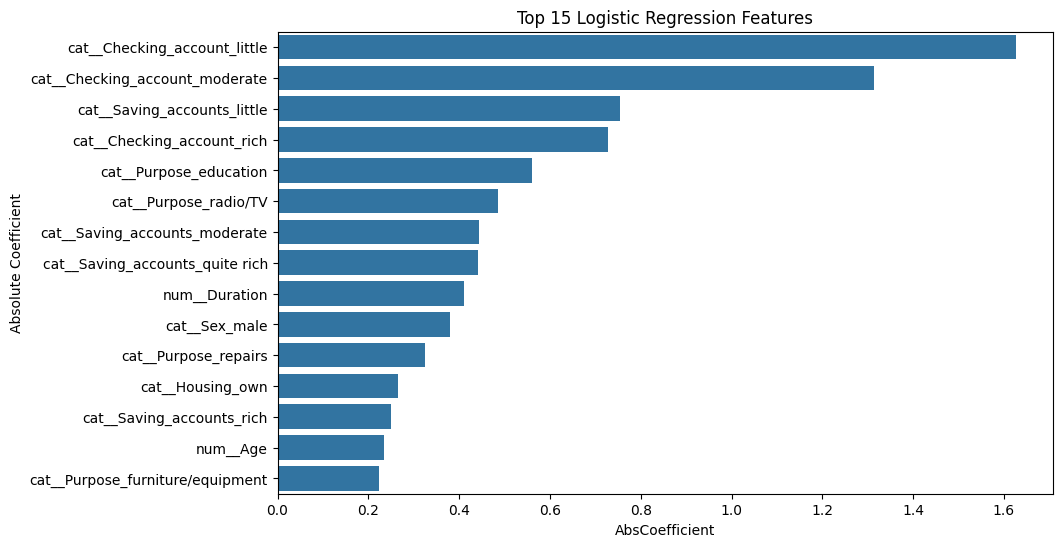

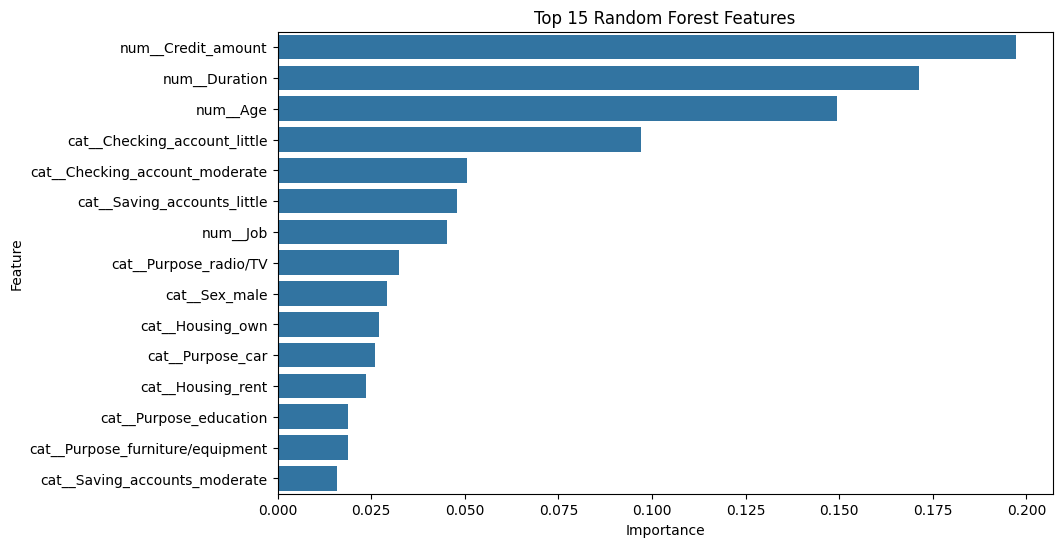

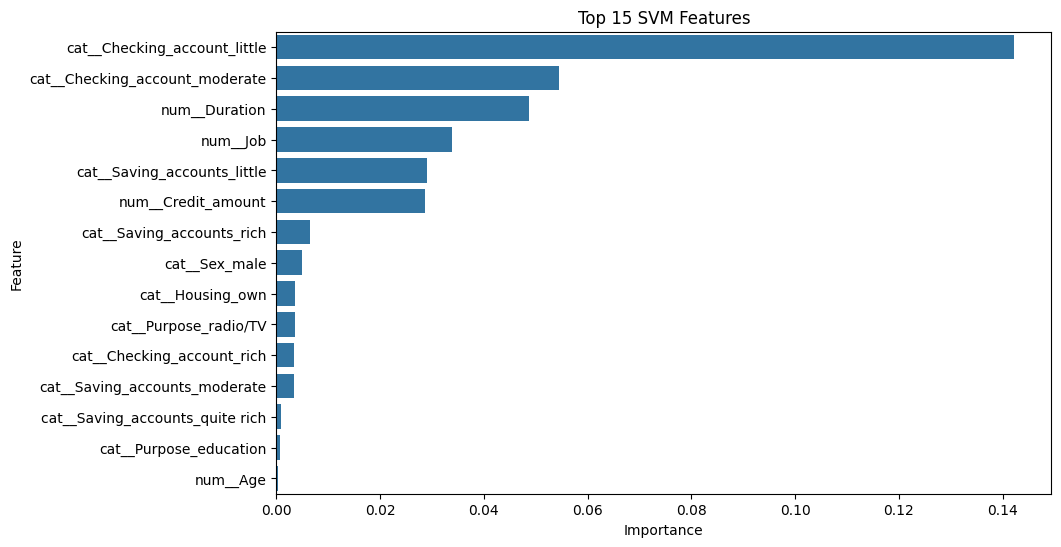

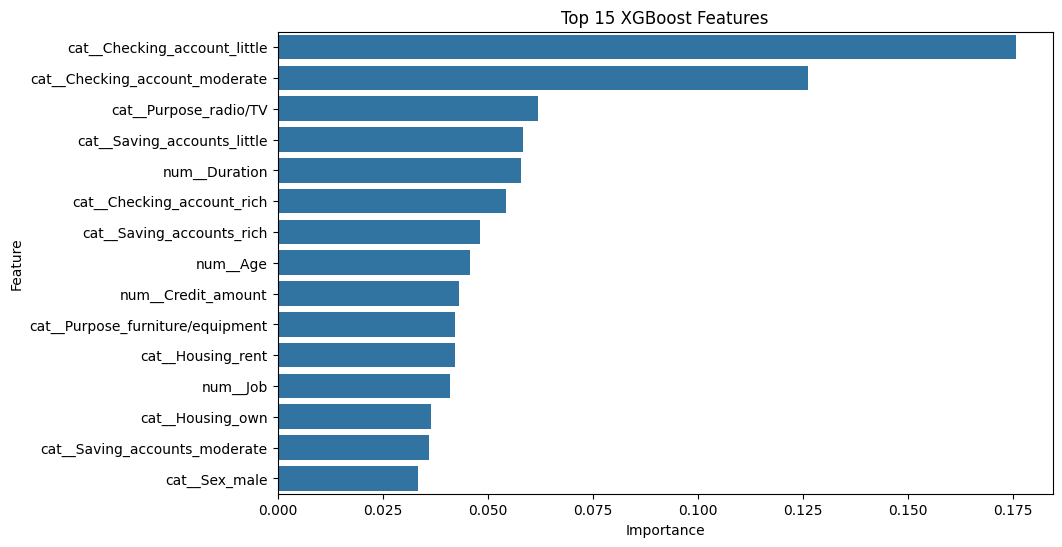

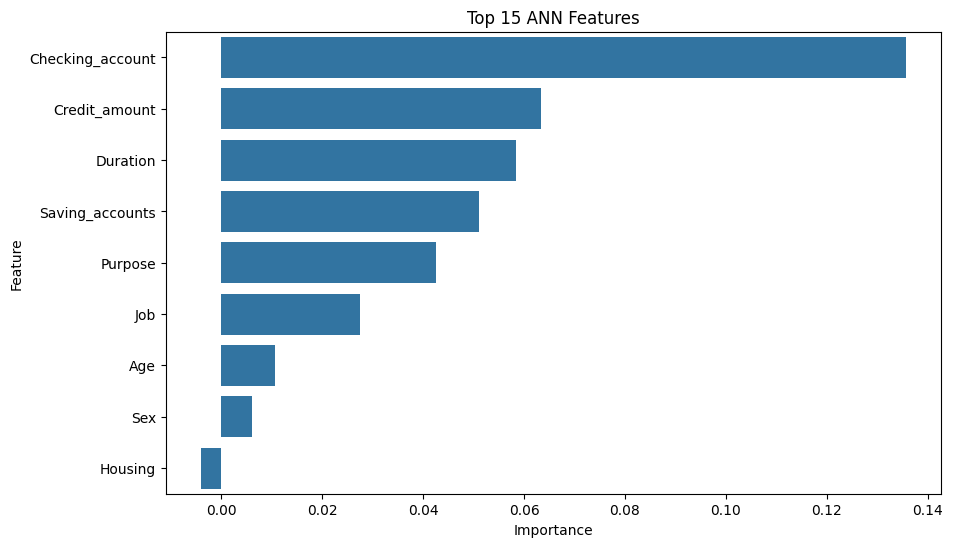

In [6]:
# Feature Importance 
log_model = log_pipeline.named_steps["classifier"]
feature_names = log_pipeline.named_steps["preprocessor"].get_feature_names_out()
importance = pd.DataFrame({"Feature": feature_names, "Coefficient": log_model.coef_[0]})
importance["AbsCoefficient"] = importance["Coefficient"].abs()
importance = importance.sort_values(by="AbsCoefficient", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(15), x="AbsCoefficient", y="Feature")
plt.title("Top 15 Logistic Regression Features")
plt.ylabel("Absolute Coefficient")
plt.show()


rf_model = rf_pipeline.named_steps["classifier"]
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importance = pd.DataFrame({"Feature": feature_names, "Importance": rf_model.feature_importances_})
importance = importance.sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Random Forest Features")
plt.show()


X_test_transformed = svm_pipeline.named_steps["preprocessor"].transform(X_test)
svm_model = svm_pipeline.named_steps["classifier"]
result = permutation_importance(svm_model, X_test_transformed, y_test, scoring="roc_auc", n_repeats=10, random_state=42)
feature_names = svm_pipeline.named_steps["preprocessor"].get_feature_names_out()
importance = pd.DataFrame({"Feature": feature_names,"Importance": result.importances_mean}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 SVM Features")
plt.show()


xgb_model = xgb_pipeline.named_steps["classifier"]
feature_names = xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()
importance = pd.DataFrame({"Feature": feature_names, "Importance": xgb_model.feature_importances_})
importance = importance.sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 XGBoost Features")
plt.show()


result = permutation_importance(ann_pipeline, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=42)
importance = pd.DataFrame({"Feature": X_test.columns, "Importance": result.importances_mean})
importance = importance.sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 ANN Features")
plt.show()

In [7]:
# Hyperparameter Tuning
param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1],
    'classifier__kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best SVM Parameters: {grid_search.best_params_}")
best_svm_model = grid_search.best_estimator_


best_pred = best_svm_model.predict(X_test)
best_prob = best_svm_model.predict_proba(X_test)[:, 1]
best_roc = roc_auc_score(y_test, best_prob)
print("Tuned SVM ROC-AUC:", best_roc)

Best SVM Parameters: {'classifier__C': 10, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}
Tuned SVM ROC-AUC: 0.7623809523809525


In [8]:
# Final Model Selection
models = {"Logistic Regression": log_pipeline, "Random Forest": rf_pipeline, "SVM": svm_pipeline, "XGBoost": xgb_pipeline, "ANN": ann_pipeline}
results = {"Logistic Regression": roc_log, "Random Forest": roc_rf, "SVM": roc_svm, "XGBoost": roc_xgb, "ANN": roc_ann}
best_model_name = max(results, key=results.get)
final_model = models[best_model_name]
print(f"Selected Model: {best_model_name}")

Selected Model: SVM


In [9]:
# Model Serialization
joblib.dump(final_model, "Credit_Card_Risk_Prediction.pkl")
print("Model saved successfully.")

Model saved successfully.
